<a href="https://colab.research.google.com/github/vverar2-hub/Q-Learning/blob/main/RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reflexione ¿Cuáles son las complejidades de RL en el mundo real?

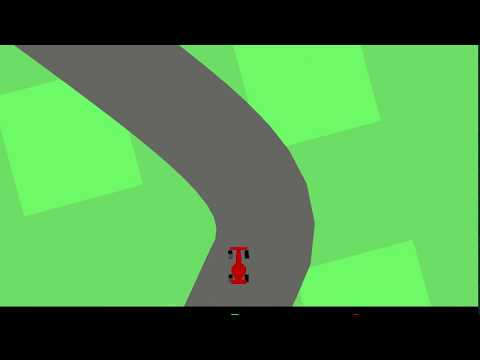

In [33]:
from IPython.display import YouTubeVideo
YouTubeVideo("Ev0wpVB7OEs", width=800, height=400)

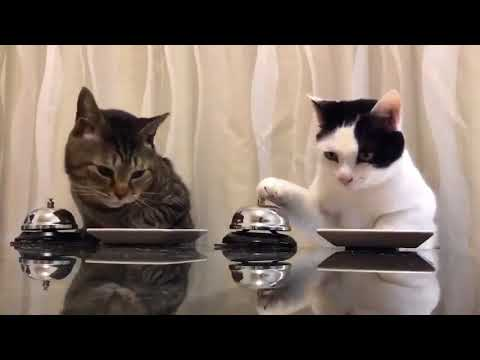

In [2]:
YouTubeVideo("lpi19vExbzc", width=800, height=400)

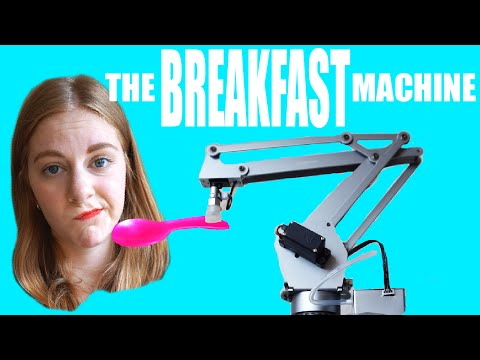

In [3]:
YouTubeVideo("E2evC2xTNWg", width=800, height=400)

Phil prepara su desayuno. Si se examina de cerca, incluso esta aparentemente mundana actividad revela una compleja red de comportamiento condicional y relaciones interconectadas de metas y submetas: caminar hacia el armario, abrirlo, seleccionar una caja de cereal y luego alcanzar, agarrar y recuperar la caja. Otros complejos y ajustados secuencias interactivas de comportamiento son necesarias para obtener un tazón, una cuchara y un cartón de leche. Cada paso implica una serie de movimientos oculares para obtener información y guiar el alcance y la locomoción. Se realizan juicios rápidos continuamente sobre cómo llevar los objetos o si es mejor transportar algunos de ellos a la mesa antes de obtener otros. Cada paso está guiado por metas, como agarrar una cuchara o llegar al refrigerador, y está al servicio de otras metas, como tener la cuchara para comer una vez que se haya preparado el cereal y, en última instancia, obtener alimentación. Ya sea consciente o no, Phil está accediendo a información sobre el estado de su cuerpo que determina sus necesidades nutricionales, nivel de hambre y preferencias alimenticias.

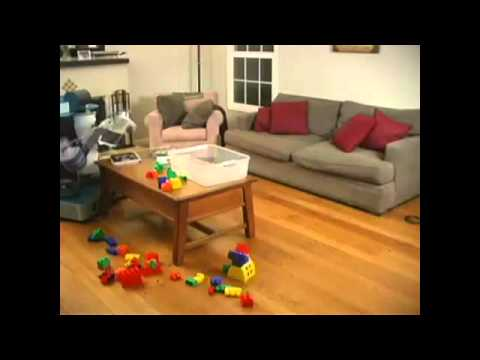

In [4]:
YouTubeVideo("qBZPSTR96N4", width=800, height=400)

En el video anterior se muestra el robot PR1 haciendo todo tipo de tareas domésticas. Sin embargo el video es un montaje, ya que PR1 está siendo operado remotamente por un humano.

# **¿Puedes reconocer los agentes, las acciones, el ambiente, la recompensa y demás elementos de RL en los anteriores ejemplos?**

# **Respuesta:** ...

# Nuestro primer agente en Python

Para simular el ambiente y el agente utilizaremos el toolkit gymnasium. La documentación completa se puede revisar en: https://gymnasium.farama.org/.

Para instalar

In [34]:
pip install "gymnasium[atari]" pygame --default-timeout=1000

Esto instalará los ambientes por defecto y adicionalmente los ambientes basados en juegos de ATARI.

Utilizaremos como ejemplo el ambiente de La laguna congelada.

“Usted y sus amigos juegan a lanzar el frisbee. El frisbee cae en una laguna que está parcialmente congelada. El objetivo es recuperar el frisbee sin caer donde se ha derretido el hielo”

Con esta premisa veamos como cargar este ambiente en gym

In [35]:
import gymnasium as gym

# Genera el ambiente
env = gym.make("FrozenLake-v1", render_mode="ansi")

# Resetea el ambiente
env.reset()

# Muestra el ambiente
print(env.render())


SFFF
FHFH
FFFH
HFFG



El argumento render_mode="ansi" retorna el ambiente como un string. El ambiente por defecto tiene 4x4 = 16 espacios que representan la laguna congelada:

F (Frozen), es seguro caminar por ese bloque

H (Hole), te ahogas y mueres

S (Start), la posición inicial del agente

G (Goal), la posición del frisbee

También podemos utilizar render_mode="rgb_array" para obtener el ambiente como una colección de píxeles o la opción human para mostrar el ambiente en una ventana independiente.

In [7]:
env = gym.make("FrozenLake-v1", render_mode="rgb_array")
env.reset()
image = env.render()

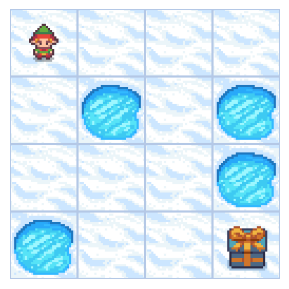

In [8]:
%matplotlib inline
from matplotlib import pyplot as plt

def plot_frame(frame):
    fig, ax = plt.subplots(figsize=(4, 3), tight_layout=True)
    ax.imshow(frame)
    ax.axis('off')

plot_frame(image)

Nota

En este ambiente se tiene completa observabilidad de los estados.

Se puede consultar directamente sobre el tamaño del espacio de estados y estado actual con:

In [9]:
# Espacio de estados
display(env.observation_space)
display(env.observation_space.n)

# Estado actual
display(env.unwrapped.s)

Discrete(16)

np.int64(16)

np.int64(0)

Podemos consultar el tamaño del espacio de acciones con:

In [10]:
# Espacio de acciones
display(env.action_space, env.action_space.n)

Discrete(4)

np.int64(4)

Las acciones son:

0: LEFT

1: DOWN

2: RIGHT

3: UP

Además debemos considerar que en este ambiente:

El agente rebota en las paredes

El hielo es resbaladizo: Las acciones tienen un componente estocástico

Podemos muestrear una acción aleatoria con la propiedad sample

In [11]:
for k in range(10):
    print(f"{k}: {env.action_space.sample()}")

0: 1
1: 1
2: 0
3: 0
4: 1
5: 1
6: 1
7: 2
8: 0
9: 1


La distribución de la acción aleatoria es uniforme

In [12]:
from collections import Counter

actions = [env.action_space.sample() for k in range(10_000)]
Counter(actions)

Counter({np.int64(0): 2490,
         np.int64(2): 2500,
         np.int64(3): 2474,
         np.int64(1): 2536})

# Actuando en el ambiente
Podemos ejecutar una acción sobre el ambiente con la función step. Esta función retorna el nuevo estado al que llegamos y la recompensa .

Recordemos este escenario es estocástico: La acción que ejecutamos no es siempre la que efectivamente se realiza.

Estoy en el estado: 0
Selecciono la acción 3
Llegué al estado: 1 y obtuve la recompensa: 0


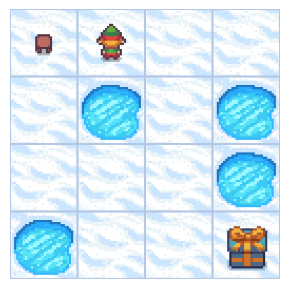

In [13]:
env.reset()
env.render()

print(f"Estoy en el estado: {env.unwrapped.s}")

a = env.action_space.sample()
print(f"Selecciono la acción {a}")

s, r, terminated, truncated, info = env.step(a)
print(f"Llegué al estado: {s} y obtuve la recompensa: {r}")

image =  env.render()
plot_frame(image)

Por ejemplo la distribución para moverme a la izquierda desde el cuadro inicial es

In [14]:
env.reset()

arrival_state = []
for k in range(10_000):
    env.reset()
    s, r, terminated, truncated, info = env.step(0)
    arrival_state.append(s)

Counter(arrival_state)

Counter({4: 3286, 0: 6714})

Es decir que:

En 2/3 de los casos reboto en la pared y me quedo donde estoy

En 1/3 de los casos me muevo hacia abajo y llego a 4

Esto también estaba indicado en info

In [15]:
info

{'prob': 0.33333333333333337}

**Recompensa y condición de término**

Existen tres condiciones de término del “episodio” (fin del juego)

Llegar al objetivo: recompensa +1

Caer en un agujero: recompensa +0

Realizar 100 pasos: recompesa +0

¿Cómo le irá a un agente con politica aleatoria?

In [16]:
from IPython.display import clear_output
from time import sleep

env = gym.make("FrozenLake-v1", render_mode="ansi")
env.reset()
step, terminated = 0, False

while not terminated:
    a = env.action_space.sample()
    s, r, terminated, truncated, info = env.step(a)
    clear_output(wait=True)
    print(f"Paso {step}, Recompensa: {r}")
    print(env.render())
    sleep(.25)
    step += 1

Paso 3, Recompensa: 0
  (Down)
SFFF
FHFH
FFFH
HFFG



**Entrenamiento con Q-Learning**
Entrenemos nuestro agente usando una tabla de Q-Learning inicialmente en cero. En cada iteración la actualizamos la tabla con:
Como el ambiente es estocástico es preferible una tasa de aprendizaje baja. Estudiemos lo que ocurre:

In [17]:
import numpy as np

env = gym.make("FrozenLake-v1", render_mode="ansi")
rewards = []
alpha, gamma = 0.1, 0.9
Q = np.zeros(shape=(env.observation_space.n, env.action_space.n))

for episode in range(10):
    env.reset()
    terminated = False
    while not terminated:
        s_current = env.unwrapped.s
        # Escoger la mejor acción
        a = np.argmax(Q[s_current, :])
        # Ejecutarla
        s_future, r, terminated, truncated, info = env.step(a)
        # Actualizar Q
        Q[s_current, a] += alpha*(r + gamma*np.max(Q[s_future, :]) - Q[s_current, a])
    rewards.append(r)

Revisemos la tabla Q y las recompensas ganadas:

In [18]:
display(Q, Counter(rewards))

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

Counter({0: 10})

¿Por qué ocurrió esto? El problema está en la siguiente línea de código:

In [19]:
    a = np.argmax(Q[s_current, :])

# Dilema de exploración y explotación: Epsilon-Greedy Q-Learning

Un problema del algoritmo Q-Learning es que es demasiado explotador.

    Siempre escoge la acción que maximiza Q: es una greedy policy.

Sin embargo, y especialmente al inicio, es crítico explorar el espacio de acciones. Se puede hacer la siguiente corrección:

Se muestrea una variable Bernoulli (binaria) con probabilidad
de ser

    Si resulta 1, entonces se sigue la política óptima (greedy)

    Si resulta 0, entonces se escoge una acción al azar

Esta estrategia se denomina Epsilon-Greedy.

Los parámetros de Q-Learning convencional son la tasa de aprendizaje, el factor de descuento y el número de episodios, es decir la cantidad de veces que se presenta el escenario al agente.

A más alto, más rápido se adoptan los cambios en la matriz Q. Sin embargo un valor muy alto puede ser perjudicial si el ambiente es estocástico. Un valor típico es
Si el aprendizaje sólo se enfoca en el presente. Por otro lado si las recompensas de largo y corto plazo tienen igual valor y se tienen problemas de convergencia.


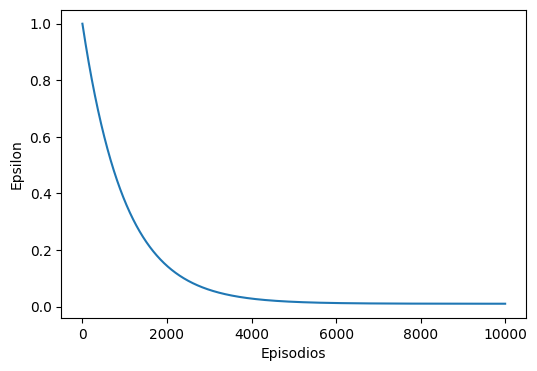

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

episodes = np.arange(10000)
epsilon_init = 1.0
epsilon_end = 0.01
epsilon_rate = 1e-3
ax.plot(episodes, epsilon_end + (epsilon_init - epsilon_end) * np.exp(-epsilon_rate*episodes));
ax.set_xlabel('Episodios')
ax.set_ylabel('Epsilon');

Entrenemos nuevamente en el ambiente de laguna congelada con Epsilon-Greedy

*   Elemento de lista
*   Elemento de lista

Q-Learning

In [21]:
%%time

env = gym.make("FrozenLake-v1", render_mode="ansi")
#env = gym.make("FrozenLake-v1", render_mode="ansi", is_slippery=False)
Q = np.zeros(shape=(env.observation_space.n, env.action_space.n))
diagnostics = {'rewards': [], 'episode_length': []}
# Hiper-parámetros
alpha, gamma, n_episodios = 0.1, 0.99, 10_000
epsilon_init, epsilon_end, epsilon_rate = 1.0, 0.01, 1e-3
epsilon = lambda episode : epsilon_end + (epsilon_init - epsilon_end) * np.exp(-epsilon_rate*episode)
n_evaluations = 100

for episode in range(n_episodios):
    env.reset()
    terminated = False
    while not terminated:
        s_current = env.unwrapped.s
        # Seleccionar la acción con política Epsilon-Greedy
        if np.random.binomial(1, p=epsilon(episode)): # Changed from not np.random.binomial(1, p=1.-epsilon(episode))
            a = env.action_space.sample()
        else:
             # Changed from ~np.all(Q[s_current, :]==0)
            a = np.argmax(Q[s_current, :]) if not np.all(Q[s_current, :]==0) else env.action_space.sample()
        s_future, r, terminated, truncated, info = env.step(a)
        Q[s_current, a] += alpha*(r + gamma*np.max(Q[s_future, :]) - Q[s_current, a])

    # Cada 100 episodios evaluamos el agente sin Epsilon-Greedy:
    if np.mod(episode, 100) == 0:
        diagnostics['rewards'].append(np.zeros(shape=(n_evaluations,)))
        diagnostics['episode_length'].append(np.zeros(shape=(n_evaluations,)))
        for k in range(n_evaluations):
            env.reset()
            terminated = False
            episode_length, episode_reward = 0, 0.0
            while not terminated:
                s_current = env.unwrapped.s
                if not np.all(Q[s_current, :]==0):
                    a = np.argmax(Q[s_current, :])
                else:
                    a = env.action_space.sample()
                s_future, r, terminated, truncated, info = env.step(a)
                episode_length += 1
                episode_reward += r
            diagnostics['rewards'][-1][k] = episode_reward
            diagnostics['episode_length'][-1][k] = episode_length

CPU times: user 27.7 s, sys: 56.5 ms, total: 27.8 s
Wall time: 32.4 s


# Diagnósticos: Debuggeando lo aprendido

El aprendizaje se puede diagnosticar observando gráficas de la evolución de la recompensa y la cantidad de pasos promedio.



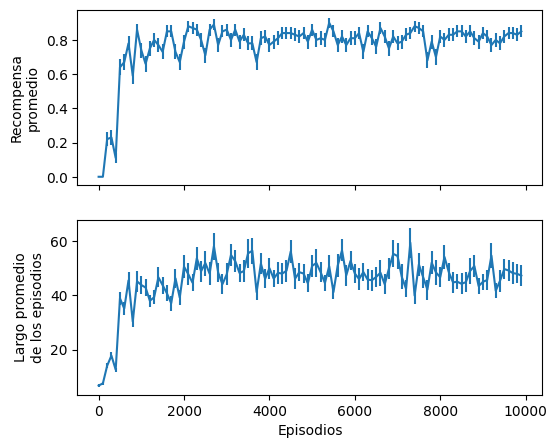

In [22]:
fig, ax = plt.subplots(2, figsize=(6, 5), sharex=True)
ax[0].errorbar(np.arange(10000//100)*100,
               np.array(diagnostics['rewards']).mean(axis=1),
               np.array(diagnostics['rewards']).std(axis=1)/np.sqrt(n_evaluations));
ax[0].set_ylabel('Recompensa\npromedio');
ax[1].errorbar(np.arange(10000//100)*100,
               np.array(diagnostics['episode_length']).mean(axis=1),
               np.array(diagnostics['episode_length']).std(axis=1)/np.sqrt(n_evaluations));
ax[1].set_xlabel('Episodios')
ax[1].set_ylabel('Largo promedio\nde los episodios');



    La recompensa y el largo de los episodios aumentan y luego tienden a estabilizarse.

Se puede verificar el aprendizaje del agente observando la tabla Q

¿Cuáles estádos acciones/estados tienen recompoensa esperada cero?

In [23]:
np.set_printoptions(precision=3)
display(Q)
display(np.arange(16).reshape(4, 4))
print(env.render())

array([[0.547, 0.493, 0.48 , 0.495],
       [0.371, 0.394, 0.197, 0.497],
       [0.408, 0.404, 0.394, 0.466],
       [0.258, 0.318, 0.329, 0.443],
       [0.576, 0.452, 0.375, 0.408],
       [0.   , 0.   , 0.   , 0.   ],
       [0.168, 0.16 , 0.436, 0.087],
       [0.   , 0.   , 0.   , 0.   ],
       [0.435, 0.425, 0.429, 0.644],
       [0.343, 0.701, 0.346, 0.314],
       [0.665, 0.413, 0.381, 0.396],
       [0.   , 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   ],
       [0.544, 0.484, 0.85 , 0.488],
       [0.72 , 0.896, 0.728, 0.7  ],
       [0.   , 0.   , 0.   , 0.   ]])

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15]])

  (Down)
SFFF
FHFH
FFFH
HFFG



**Probando nuestro agente en vivo**



In [24]:
env.reset()
step, terminated = 0, False

while not terminated:
    s_current = env.unwrapped.s
    a = np.argmax(Q[s_current, :])
    s_future, r, terminated, truncated, info = env.step(a)
    clear_output(wait=True)
    print(f"Paso {step}, Recompensa: {r}")
    print(env.render())
    sleep(.2)
    step += 1

Paso 60, Recompensa: 0
  (Right)
SFFF
FHFH
FFFH
HFFG



¿Qué ocurre si el ambiente no es estocástico? Utilice

In [25]:
#env = gym.make("FrozenLake-v1", render_mode="ansi", is_slippery=False)

Elige un entorno simple del toolkit Gymnasium (por ejemplo, "Taxi-v4" o "CliffWalking-v0"), adapta el código de Q-Learning para que funcione con este nuevo entorno y analiza las diferencias en el espacio de estados y acciones, y cómo afectan al algoritmo de aprendizaje.

El primer paso es seleccionar un nuevo entorno y crear una instancia. Se elige "Taxi-v3", como se sugiere, e inspeccionamos sus espacios de observación y acción.

In [26]:
import gymnasium as gym

# Crear el entorno Taxi-v4
env_taxi = gym.make("Taxi-v4")

# Inspeccionar el espacio de observación y el espacio de acción
print("Observation Space:", env_taxi.observation_space)
print("Action Space:", env_taxi.action_space)

Observation Space: Discrete(500)
Action Space: Discrete(6)


Una vez creado el entorno e inspeccionados sus espacios, el siguiente paso es adaptar el código de Q-Learning a este nuevo entorno. Esto implica inicializar la tabla Q con las dimensiones correctas según los espacios de observación y acción de "Taxi-v4" y, a continuación, ejecutar el bucle de entrenamiento. También se incluirá la colección de diagnósticos para su posterior análisis.

In [27]:
import numpy as np
from collections import Counter

#env_taxi = gym.make("Taxi-v4", render_mode="ansi") # Usando el modo de renderizado predeterminado
env_taxi = gym.make("Taxi-v4") # Usando el modo de renderizado predeterminado

Q_taxi = np.zeros(shape=(env_taxi.observation_space.n, env_taxi.action_space.n))
diagnostics_taxi = {'rewards': [], 'episode_length': []}

# Hiperparámetros (se pueden ajustar más adelante)
alpha, gamma, n_episodios = 0.1, 0.99, 10_000
epsilon_init, epsilon_end, epsilon_rate = 1.0, 0.01, 1e-3
epsilon = lambda episode : epsilon_end + (epsilon_init - epsilon_end) * np.exp(-epsilon_rate*episode)
n_evaluations = 100

for episode in range(n_episodios):
    state, info = env_taxi.reset()
    terminated = False
    truncated = False

    while not terminated and not truncated:
        s_current = state
        # Seleccionar acción con la política Epsilon-Greedy
        if np.random.binomial(1, p=epsilon(episode)):
            a = env_taxi.action_space.sample()
        else:
            a = np.argmax(Q_taxi[s_current, :]) if not np.all(Q_taxi[s_current, :]==0) else env_taxi.action_space.sample()

        state, r, terminated, truncated, info = env_taxi.step(a)
        s_future = state

        # Actualización Q
        Q_taxi[s_current, a] += alpha*(r + gamma*np.max(Q_taxi[s_future, :]) - Q_taxi[s_current, a])

    # Evaluar el agente periódicamente sin Epsilon-Greedy
    if np.mod(episode, 100) == 0:
        diagnostics_taxi['rewards'].append(np.zeros(shape=(n_evaluations,)))
        diagnostics_taxi['episode_length'].append(np.zeros(shape=(n_evaluations,)))
        for k in range(n_evaluations):
            state, info = env_taxi.reset()
            terminated = False
            truncated = False
            episode_length, episode_reward = 0, 0.0
            while not terminated and not truncated:
                s_current = state
                if not np.all(Q_taxi[s_current, :]==0):
                    a = np.argmax(Q_taxi[s_current, :])
                else:
                    a = env_taxi.action_space.sample()
                state, r, terminated, truncated, info = env_taxi.step(a)
                episode_length += 1
                episode_reward += r
            diagnostics_taxi['rewards'][-1][k] = episode_reward
            diagnostics_taxi['episode_length'][-1][k] = episode_length

env_taxi.close()

El agente ha sido entrenado en el entorno "Taxi-v4". El siguiente paso es analizar los resultados del entrenamiento trazando la evolución de la recompensa promedio y la duración del episodio a lo largo de los episodios, de forma similar al análisis realizado para el entorno FrozenLake.

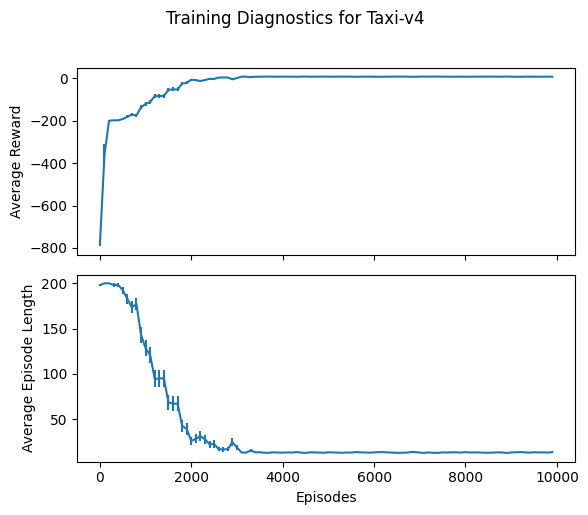

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, figsize=(6, 5), sharex=True)
ax[0].errorbar(np.arange(n_episodios//100)*100,
               np.array(diagnostics_taxi['rewards']).mean(axis=1),
               np.array(diagnostics_taxi['rewards']).std(axis=1)/np.sqrt(n_evaluations));
ax[0].set_ylabel('Average Reward');
ax[1].errorbar(np.arange(n_episodios//100)*100,
               np.array(diagnostics_taxi['episode_length']).mean(axis=1),
               np.array(diagnostics_taxi['episode_length']).std(axis=1)/np.sqrt(n_evaluations));
ax[1].set_xlabel('Episodes')
ax[1].set_ylabel('Average Episode Length');
plt.suptitle('Training Diagnostics for Taxi-v4', y=1.02)
plt.tight_layout()

Los gráficos muestran el progreso del entrenamiento en el entorno Taxi-v4. El siguiente paso es analizar y comparar las diferencias en los espacios de estado y acción de FrozenLake y Taxi-v4, y analizar su impacto en el algoritmo Q-Learning y el rendimiento del entrenamiento observado.

In [29]:
# Comparar espacios de estado y acción
print("FrozenLake Observation Space:", env.observation_space)
print("FrozenLake Action Space:", env.action_space)
print("\nTaxi-v4 Observation Space:", env_taxi.observation_space)
print("Taxi-v4 Action Space:", env_taxi.action_space)

# Discusión sobre las diferencias y el impacto
print("\nAnalysis of Differences:")
print("- FrozenLake has a discrete state space of size 16 (4x4 grid). Taxi-v4 has a discrete state space of size 500.")
print("  A larger state space means the Q-table is significantly larger for Taxi-v4 (500 states * 6 actions) compared to FrozenLake (16 states * 4 actions).")
print("  This larger Q-table requires more memory and potentially more episodes to explore adequately and converge.")
print("- FrozenLake has 4 discrete actions (Left, Down, Right, Up). Taxi-v4 has 6 discrete actions (move south, north, east, west, pickup passenger, drop off passenger).")
print("  A larger action space also contributes to the size of the Q-table and increases the number of possible state-action pairs to explore.")
print("- The dynamics of the environments are different. FrozenLake is a grid world with stochastic transitions (slippery ice). Taxi-v4 involves picking up and dropping off a passenger at specific locations, which adds more complexity to the state definition and reward structure.")
print("- The reward structure is also different. FrozenLake gives a +1 reward for reaching the goal and 0 otherwise (with penalties for falling in holes implicitly handled by episode termination). Taxi-v4 has a reward of +20 for a successful dropoff, -10 for an illegal pickup or dropoff, and -1 for each step.")
print("  The more complex reward structure in Taxi-v4 requires the agent to learn a longer sequence of actions to achieve a significant positive reward.")
print("\nImpact on Q-Learning:")
print("- The larger state and action spaces in Taxi-v3 lead to a much larger Q-table. This can make convergence slower and require more training data (episodes).")
print("- The complexity of the task and reward structure in Taxi-v4 means the agent needs to learn more intricate policies compared to navigating a simple grid in FrozenLake.")
print("- The stochasticity in FrozenLake's transitions requires a smaller learning rate (alpha) or more exploration. While Taxi-v3 is deterministic in transitions (except for the initial state), the goal-oriented nature makes exploration of the state-action space crucial.")
print("- The plots show that for Taxi-v4, the average reward starts very low (due to penalties) and gradually increases, while the episode length tends to decrease as the agent learns a more efficient policy. This is a different learning curve compared to FrozenLake, where the reward is sparse and the primary goal is to reach the end state.")

FrozenLake Observation Space: Discrete(16)
FrozenLake Action Space: Discrete(4)

Taxi-v4 Observation Space: Discrete(500)
Taxi-v4 Action Space: Discrete(6)

Analysis of Differences:
- FrozenLake has a discrete state space of size 16 (4x4 grid). Taxi-v4 has a discrete state space of size 500.
  A larger state space means the Q-table is significantly larger for Taxi-v4 (500 states * 6 actions) compared to FrozenLake (16 states * 4 actions).
  This larger Q-table requires more memory and potentially more episodes to explore adequately and converge.
- FrozenLake has 4 discrete actions (Left, Down, Right, Up). Taxi-v4 has 6 discrete actions (move south, north, east, west, pickup passenger, drop off passenger).
  A larger action space also contributes to the size of the Q-table and increases the number of possible state-action pairs to explore.
- The dynamics of the environments are different. FrozenLake is a grid world with stochastic transitions (slippery ice). Taxi-v4 involves picking up 

In [30]:
import gymnasium as gym

# Crear el entorno CliffWalking-v0
env_cliff = gym.make("CliffWalking-v1") # Changed from "CliffWalking-v0"

# Inspeccionar el espacio de observación y el espacio de acción
print("Observation Space:", env_cliff.observation_space)
print("Action Space:", env_cliff.action_space)

Observation Space: Discrete(48)
Action Space: Discrete(4)


In [31]:
# Implementación de la política UCB (Upper Confidence Bound)
import numpy as np

def ucb_policy(Q, N, state, c):
    """
    Selecciona una acción usando la política UCB.

    Args:
        Q (np.ndarray): Tabla Q.
        N (np.ndarray): Tabla de conteo de visitas estado-acción.
        state (int): Estado actual.
        c (float): Parámetro de exploración.

    Returns:
        int: Acción seleccionada.
    """
    n_a = Q.shape[1]
    ucb_values = np.zeros(n_a)
    total_visits = np.sum(N[state, :])

    for a in range(n_a):
        if N[state, a] == 0:
            ucb_values[a] = float('inf') # Explorar acciones no visitadas
        else:
            ucb_values[a] = Q[state, a] + c * np.sqrt(np.log(total_visits) / N[state, a])

    return np.argmax(ucb_values)

# Ejemplo de uso (requiere tablas Q y N inicializadas)
# Q = np.zeros(shape=(env_taxi.observation_space.n, env_taxi.action_space.n))
# N = np.zeros(shape=(env_taxi.observation_space.n, env_taxi.action_space.n))
# c_param = 2.0 # Parámetro de exploración UCB
# action = ucb_policy(Q, N, current_state, c_param)

In [32]:
# Implementación de la política Thompson Sampling
import numpy as np

def thompson_sampling_policy(Q, alpha_counts, beta_counts, state):
    """
    Selecciona una acción usando la política Thompson Sampling.

    Args:
        Q (np.ndarray): Tabla Q (no estrictamente necesaria para la selección, pero se usa para la estructura).
        alpha_counts (np.ndarray): Parámetros alpha para la distribución Beta (éxitos).
        beta_counts (np.ndarray): Parámetros beta para la distribución Beta (fracasos).
        state (int): Estado actual.

    Returns:
        int: Acción seleccionada.
    """
    n_a = Q.shape[1]
    sampled_values = np.zeros(n_a)

    for a in range(n_a):
        # Muestrear de una distribución Beta para cada acción
        sampled_values[a] = np.random.beta(alpha_counts[state, a] + 1, beta_counts[state, a] + 1)

    return np.argmax(sampled_values)

# Ejemplo de uso (requiere tablas alpha_counts y beta_counts inicializadas)
# alpha_counts = np.zeros(shape=(env_taxi.observation_space.n, env_taxi.action_space.n))
# beta_counts = np.zeros(shape=(env_taxi.observation_space.n, env_taxi.action_space.n))
# action = thompson_sampling_policy(Q_taxi, alpha_counts, beta_counts, current_state)